In [2]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import json
import plotly.express as px
from geopy.distance import geodesic
import statistics

## Data Cleaning

In [3]:
path = Path(r"source_data\crime.csv")
path

WindowsPath('source_data/crime.csv')

In [4]:
df = pd.read_csv(path, encoding='cp1252')
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type_id,criminal-mischief-other,criminal-mischief-other
offense_category_id,public-disorder,public-disorder
first_occurrence_date,2/10/2022 2:50:00 AM,7/7/2021 9:02:00 PM
last_occurrence_date,NaN,NaN
reported_date,2/10/2022 3:16:00 AM,7/8/2021 12:55:00 AM
incident_address,1107 N SANTA FE DR,815 16TH ST


In [5]:
df.dtypes

incident_id                 int64
offense_id                  int64
offense_code                int64
offense_code_extension      int64
offense_type_id            object
offense_category_id        object
first_occurrence_date      object
last_occurrence_date       object
reported_date              object
incident_address           object
geo_x                     float64
geo_y                     float64
geo_lon                   float64
geo_lat                   float64
district_id                object
precinct_id                 int64
neighborhood_id            object
is_crime                    int64
is_traffic                  int64
victim_count                int64
dtype: object

In [6]:
df.isna().sum()

incident_id                    0
offense_id                     0
offense_code                   0
offense_code_extension         0
offense_type_id                0
offense_category_id            0
first_occurrence_date          0
last_occurrence_date      175556
reported_date                  0
incident_address           15503
geo_x                      15503
geo_y                      15503
geo_lon                    15769
geo_lat                    15769
district_id                   57
precinct_id                    0
neighborhood_id              689
is_crime                       0
is_traffic                     0
victim_count                   0
dtype: int64

In [7]:
df.fillna('', inplace=True)

In [8]:
df.isna().sum()

incident_id               0
offense_id                0
offense_code              0
offense_code_extension    0
offense_type_id           0
offense_category_id       0
first_occurrence_date     0
last_occurrence_date      0
reported_date             0
incident_address          0
geo_x                     0
geo_y                     0
geo_lon                   0
geo_lat                   0
district_id               0
precinct_id               0
neighborhood_id           0
is_crime                  0
is_traffic                0
victim_count              0
dtype: int64

In [9]:
df.first_occurrence_date = pd.to_datetime(df['first_occurrence_date'])
df.last_occurrence_date = pd.to_datetime(df['last_occurrence_date'])
df.reported_date = pd.to_datetime(df['reported_date'])

C:\Users\Ben\AppData\Local\Temp\ipykernel_17484\1886467645.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.last_occurrence_date = pd.to_datetime(df['last_occurrence_date'])


In [10]:
df.district_id.unique()
df.district_id = df.district_id.replace('', 'unknown')
df.district_id = df.district_id.replace('U', 'unknown')
df.district_id.unique()

array(['1', '6', '4', '5', '2', '3', '7', 'unknown'], dtype=object)

In [11]:
# # Find any nans
# df[df.isna().any(axis=1)]
# # Or
# df[df.isnull().any(axis=1)]

# Find nans within col
df[df.district_id.isna()]

,incident_id,offense_id,offense_code,offense_code_extension,offense_type_id,offense_category_id,first_occurrence_date,last_occurrence_date,reported_date,incident_address,geo_x,geo_y,geo_lon,geo_lat,district_id,precinct_id,neighborhood_id,is_crime,is_traffic,victim_count


In [12]:
df.precinct_id.unique()

array([123, 611, 111, 411, 521, 113, 623, 212, 213, 211, 523, 511, 313,
       621, 412, 612, 322, 221, 512, 121, 122, 112, 622, 522, 311, 223,
       314, 422, 222, 423, 323, 321, 759, 312, 421, 324, 999, 316, 436,
       532, 232], dtype=int64)

In [13]:
df.neighborhood_id.unique()
df.neighborhood_id = df.neighborhood_id.replace('', 'unknown')
df.neighborhood_id.unique()

array(['lincoln-park', 'cbd', 'berkeley', 'barnum', 'montbello',
       'highland', 'capitol-hill', 'clayton', 'congress-park', 'whittier',
       'barnum-west', 'gateway-green-valley-ranch', 'central-park',
       'platt-park', 'north-capitol-hill', 'athmar-park', 'union-station',
       'washington-virginia-vale', 'northeast-park-hill', 'west-colfax',
       'five-points', 'westwood', 'civic-center', 'sunnyside',
       'cheesman-park', 'city-park-west', 'baker', 'east-colfax',
       'skyland', 'university-hills', 'overland', 'west-highland',
       'valverde', 'college-view-south-platte', 'jefferson-park',
       'cherry-creek', 'hale', 'harvey-park-south', 'hampden', 'rosedale',
       'globeville', 'goldsmith', 'lowry-field', 'speer',
       'elyria-swansea', 'chaffee-park', 'villa-park', 'sun-valley',
       'dia', 'cory-merrill', 'cole', 'harvey-park',
       'washington-park-west', 'washington-park', 'mar-lee', 'university',
       'bear-valley', 'hampden-south', 'belcaro', 'c

In [14]:
df.is_crime = df.is_crime.apply(lambda x: True if x == 1 else False)
df.is_traffic = df.is_traffic.apply(lambda x: True if x == 1 else False)
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type_id,criminal-mischief-other,criminal-mischief-other
offense_category_id,public-disorder,public-disorder
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_date,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_address,1107 N SANTA FE DR,815 16TH ST


In [15]:
df.dtypes

incident_id                        int64
offense_id                         int64
offense_code                       int64
offense_code_extension             int64
offense_type_id                   object
offense_category_id               object
first_occurrence_date     datetime64[ns]
last_occurrence_date      datetime64[ns]
reported_date             datetime64[ns]
incident_address                  object
geo_x                             object
geo_y                             object
geo_lon                           object
geo_lat                           object
district_id                       object
precinct_id                        int64
neighborhood_id                   object
is_crime                            bool
is_traffic                          bool
victim_count                       int64
dtype: object

In [16]:
df.precinct_id = df.precinct_id.astype(str)
df.dtypes

incident_id                        int64
offense_id                         int64
offense_code                       int64
offense_code_extension             int64
offense_type_id                   object
offense_category_id               object
first_occurrence_date     datetime64[ns]
last_occurrence_date      datetime64[ns]
reported_date             datetime64[ns]
incident_address                  object
geo_x                             object
geo_y                             object
geo_lon                           object
geo_lat                           object
district_id                       object
precinct_id                       object
neighborhood_id                   object
is_crime                            bool
is_traffic                          bool
victim_count                       int64
dtype: object

In [17]:
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type_id,criminal-mischief-other,criminal-mischief-other
offense_category_id,public-disorder,public-disorder
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_date,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_address,1107 N SANTA FE DR,815 16TH ST


In [18]:
df.rename(mapper={
    'offense_type_id': 'offense_type',
    'offense_category_id': 'offense_category',
    'incident_address': 'incident_street_address',
    'geo_lon': 'incident_longitude',
    'geo_lat': 'incident_latitude',
    'neighborhood_id': 'neighborhood_name',
    'first_occurrence_date': 'first_occurrence_timestamp',
    'last_occurrence_date': 'last_occurrence_timestamp',
    'reported_date': 'report_timestamp',
}, axis=1, inplace=True)
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type,criminal-mischief-other,criminal-mischief-other
offense_category,public-disorder,public-disorder
first_occurrence_timestamp,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_timestamp,NaT,NaT
report_timestamp,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST


In [19]:
df['first_occurrence_date'] = df.first_occurrence_timestamp.dt.date
df['first_occurrence_year_num'] = df.first_occurrence_timestamp.dt.year
df['first_occurrence_month_num'] = df.first_occurrence_timestamp.dt.month
df['first_occurrence_day_of_month_num'] = df.first_occurrence_timestamp.dt.day
df['first_occurrence_day_name'] = df.first_occurrence_timestamp.dt.day_name()
df['first_occurrence_day_of_week_num'] = df.first_occurrence_timestamp.dt.day_of_week

df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type,criminal-mischief-other,criminal-mischief-other
offense_category,public-disorder,public-disorder
first_occurrence_timestamp,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_timestamp,NaT,NaT
report_timestamp,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST


## EDA & Visualizations

In [21]:
df.offense_category.unique()

array(['public-disorder', 'drug-alcohol', 'sexual-assault',
       'other-crimes-against-persons', 'all-other-crimes',
       'white-collar-crime', 'murder', 'robbery', 'aggravated-assault',
       'arson', 'burglary', 'larceny', 'theft-from-motor-vehicle',
       'auto-theft'], dtype=object)

### Incident Metrics [Bar Charts]

#### What is the breakdown of incidents by offense category?

In [22]:
# Get incident counts by offense category for plot
grouped = df.groupby(['offense_category'])['incident_id'].count().reset_index()
grouped.isnull().sum()

grouped.sort_values('incident_id', ascending=True, inplace=True)
grouped

,offense_category,incident_id
7,murder,412
2,arson,829
11,sexual-assault,4297
13,white-collar-crime,6706
10,robbery,6972
0,aggravated-assault,17213
8,other-crimes-against-persons,20486
5,drug-alcohol,21804
4,burglary,27661
1,all-other-crimes,46768


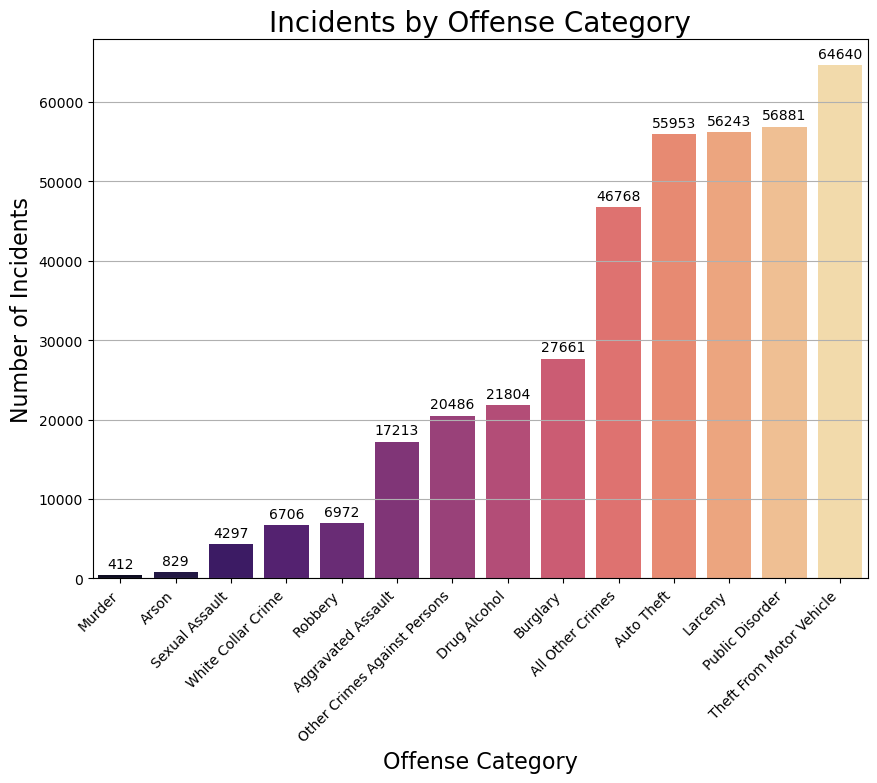

In [24]:
# Create bar chart
incidents_offense_ax = sns.barplot(data=grouped, x='offense_category', y='incident_id', palette='magma')

fig = plt.gcf()
fig.set_size_inches(10, 7)

# Add value labels automatically
for container in incidents_offense_ax.containers:
    incidents_offense_ax.bar_label(container, fmt='%.f', padding=3)

# Add title
incidents_offense_ax.set_title('Incidents by Offense Category', fontsize=20)

# Adjust axis labels
incidents_offense_ax.set_xlabel('Offense Category', fontsize=16)
incidents_offense_ax.set_ylabel('Number of Incidents', fontsize=16)

# Adjust xticks
orig_labels = [label.get_text() for label in plt.xticks()[1]]
incidents_offense_ax.set_xticklabels([(i.replace('-', ' ').title()) for i in orig_labels])
plt.xticks(rotation=45, ha='right')

incidents_offense_ax.grid(visible=True, axis='y')
plt.savefig(
    'images/IncidentMetrics_IncidentsByOffenseCategory[BarCharts].png',
    dpi=300,
    bbox_inches='tight'
    )
plt.show()

#### What is the breakdown of incidents by district *and* offense category?

In [25]:
# Calculate number of incidents by district by offense category for grouped bar chart
grouped_by_district = df.groupby(['district_id', 'offense_category'])['incident_id'].count().reset_index()
grouped_by_district = grouped_by_district.sort_values(
    by=['district_id', 'incident_id'],
    ascending=[True, True]
    )
grouped_by_district

,district_id,offense_category,incident_id
7,1,murder,74
2,1,arson,146
11,1,sexual-assault,653
13,1,white-collar-crime,735
10,1,robbery,1116
...,...,...,...
101,unknown,auto-theft,42
106,unknown,other-crimes-against-persons,50
107,unknown,public-disorder,58
103,unknown,drug-alcohol,72


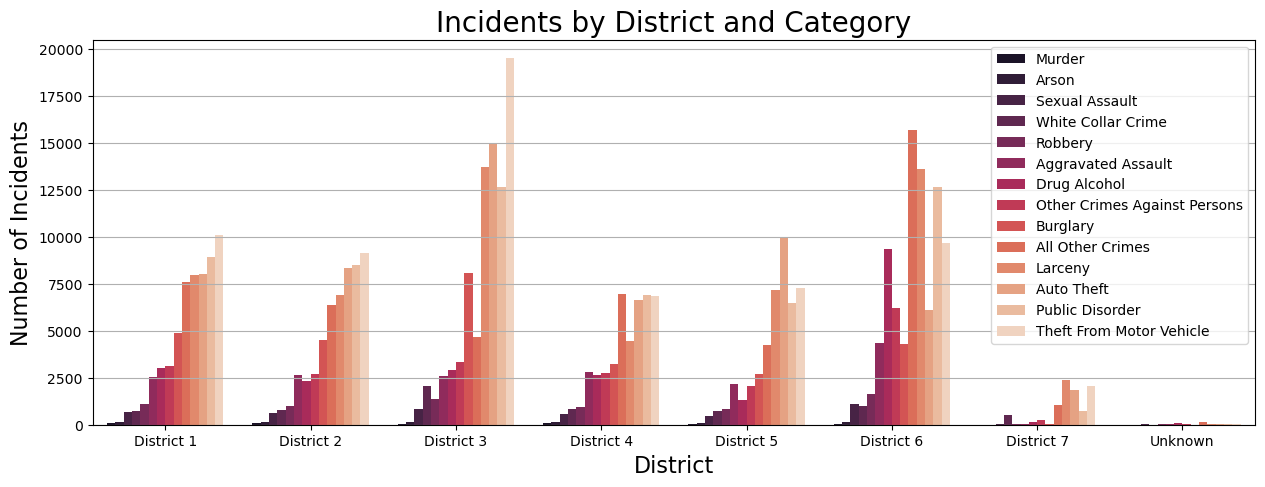

In [28]:
incidents_district_ax = sns.barplot(data=grouped_by_district, x='district_id', y='incident_id', hue='offense_category', palette='rocket')
sns.move_legend(incidents_district_ax, 'upper right')

# Add title
incidents_district_ax.set_title('Incidents by District and Category', fontsize=20)

# Adjust axis labels
incidents_district_ax.set_xlabel('District', fontsize=16)
incidents_district_ax.set_ylabel('Number of Incidents', fontsize=16)

# Adjust xtick labels
orig_labels = [i.get_text() for i in plt.xticks()[1]]
incidents_district_ax.set_xticklabels([f"District {i}" if i != 'unknown' else 'Unknown' for i in orig_labels ])

# Adjust legend
plt.legend(fontsize=10)
handles, legend_labels = incidents_district_ax.get_legend_handles_labels()
incidents_district_ax.legend(handles=handles, labels=[i.replace('-', ' ').title() for i in legend_labels])

fig = plt.gcf()
fig.set_size_inches(15, 5)

incidents_district_ax.grid(visible=True, axis='y')
plt.savefig(
    'images/IncidentMetrics_IncidentsByDistrict&OffenseCategory[BarCharts].png',
    dpi=300,
    bbox_inches='tight'
    )
plt.show()

### Incidents Over Time [Line Charts]

In [29]:
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type,criminal-mischief-other,criminal-mischief-other
offense_category,public-disorder,public-disorder
first_occurrence_timestamp,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_timestamp,NaT,NaT
report_timestamp,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST


In [30]:
subset_temporal_cols = [
        'first_occurrence_date',
        'report_timestamp',
    ]


for col in subset_temporal_cols:
    print(col, ' min ', df[col].min())
    print(col, ' max ', df[col].max())
    print()

first_occurrence_date  min  2018-01-02
first_occurrence_date  max  2023-10-03

report_timestamp  min  2018-01-02 01:41:00
report_timestamp  max  2023-10-03 22:12:00



#### How have incidents changed over time?
- Based on first occurrence date

In [31]:
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type,criminal-mischief-other,criminal-mischief-other
offense_category,public-disorder,public-disorder
first_occurrence_timestamp,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_timestamp,NaT,NaT
report_timestamp,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST


In [32]:
yearly_incidents = df.groupby(['first_occurrence_year_num'])['incident_id'].count().reset_index()
yearly_incidents.sort_values(
    by='first_occurrence_year_num',
    ascending=True,
    inplace=True
)
yearly_incidents

,first_occurrence_year_num,incident_id
0,2018,57154
1,2019,57640
2,2020,63784
3,2021,72623
4,2022,77098
5,2023,58566


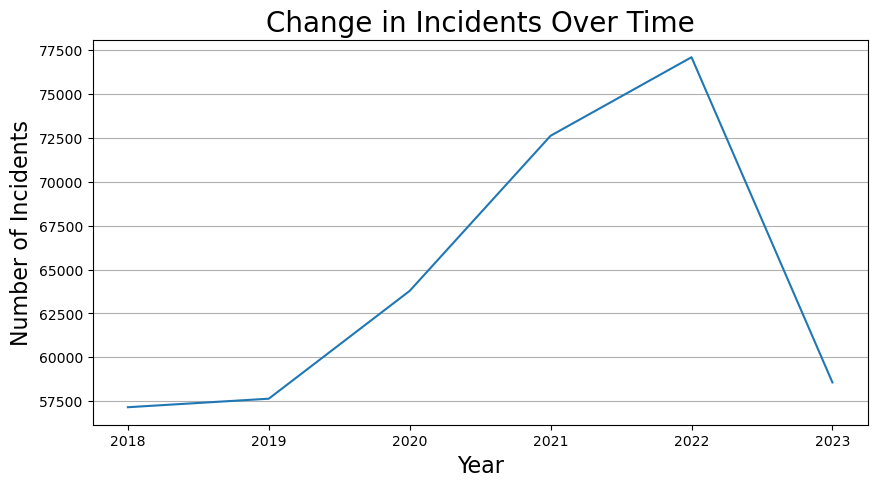

In [34]:
yearly_incidents_ax = sns.lineplot(data=yearly_incidents, x='first_occurrence_year_num', y='incident_id')

# Add title
yearly_incidents_ax.set_title('Change in Incidents Over Time', fontsize=20)

# Adjust axis labels
yearly_incidents_ax.set_xlabel('Year', fontsize=16)
yearly_incidents_ax.set_ylabel('Number of Incidents', fontsize=16)

yearly_incidents_fig = plt.gcf()
yearly_incidents_fig.set_size_inches(10, 5)

yearly_incidents_ax.grid(visible=True, axis='y')
plt.savefig(
    'images/IncidentsOverTime_ChangeInIncidentsOverTime[LineCharts].png',
    dpi=300,
    bbox_inches='tight'
    )
plt.show()

#### How have violent vs non-violent incidents changed over time?

- Plotting each offense type would be very messy
- Instead will create a new feature to bucket offenses (violent or non-violent)

In [35]:
violent_crimes = [
    'sexual-assault',
    'other-crimes-against-persons',
    'murder',
    'robbery',
    'aggravated-assault',
    'arson',
    'burglary',
]
non_violent_crimes = [
    'public-disorder',
    'drugs-alchohol',
    'all-other-crimes',
    'white-collar-crime',
    'larceny',
    'theft-from-motor-vehicle',
    'auto-theft'
]
print(len(violent_crimes) + len(non_violent_crimes) == len(df.offense_category.unique()))


df['is_violent_crime'] = df['offense_category'].isin(violent_crimes)

display(pd.concat([
    df.head(3).T,
    df.tail(3).T
    ], axis=1
))

True


,0,1,2,386862,386863,386864
incident_id,202268791,2021387586,2020641486,2023533509,2023533048,2023532323
offense_id,202268791299900,2021387586299900,2020641486299900,2023533509131506,2023533048131506,2023532323131506
offense_code,2999,2999,2999,1315,1315,1315
offense_code_extension,0,0,0,6,6,6
offense_type,criminal-mischief-other,criminal-mischief-other,criminal-mischief-other,agg-aslt-shoot,agg-aslt-shoot,agg-aslt-shoot
offense_category,public-disorder,public-disorder,public-disorder,aggravated-assault,aggravated-assault,aggravated-assault
first_occurrence_timestamp,2022-02-10 02:50:00,2021-07-07 21:02:00,2020-10-29 01:30:00,2023-10-03 10:44:00,2023-10-03 05:30:00,2023-10-02 17:47:00
last_occurrence_timestamp,NaT,NaT,NaT,NaT,NaT,NaT
report_timestamp,2022-02-10 03:16:00,2021-07-08 00:55:00,2020-10-29 04:31:00,2023-10-03 12:03:00,2023-10-03 09:47:00,2023-10-02 18:16:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST,4745 N FEDERAL BLVD,N JOLIET ST / E 55TH AVE,585 S ALTON WAY,1198 N SHERIDAN BLVD


In [36]:
yearly_violent_nonviolent = df.groupby(['first_occurrence_year_num', 'is_violent_crime'])['incident_id'].count().reset_index()
yearly_violent_nonviolent.is_violent_crime = yearly_violent_nonviolent.is_violent_crime.apply(
    lambda x: 'Violent Crime' if x == True else 'Non-Violent Crime')
yearly_violent_nonviolent

,first_occurrence_year_num,is_violent_crime,incident_id
0,2018,Non-Violent Crime,45625
1,2018,Violent Crime,11529
2,2019,Non-Violent Crime,45378
3,2019,Violent Crime,12262
4,2020,Non-Violent Crime,50111
5,2020,Violent Crime,13673
6,2021,Non-Violent Crime,58194
7,2021,Violent Crime,14429
8,2022,Non-Violent Crime,62648
9,2022,Violent Crime,14450


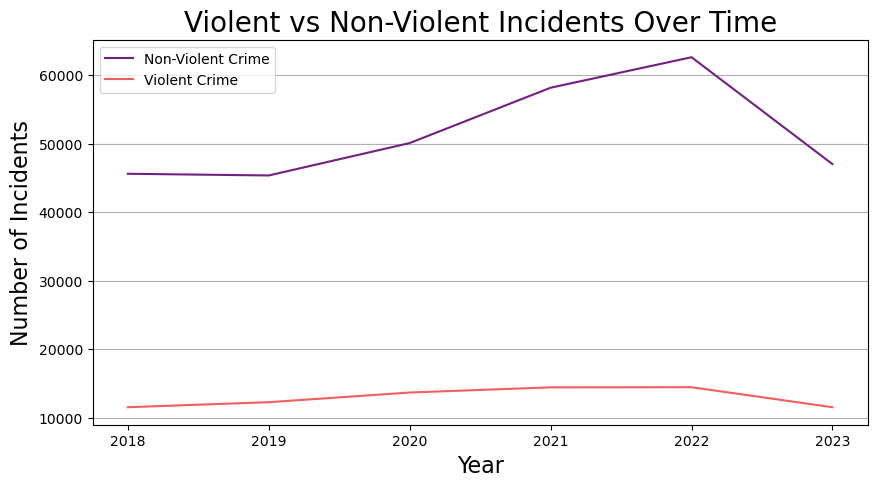

In [37]:
yearly_violent_nonviolent_ax = sns.lineplot(
    data=yearly_violent_nonviolent,
    x='first_occurrence_year_num',
    y='incident_id',
    hue='is_violent_crime',
    palette='magma'
    )

# Add title
yearly_violent_nonviolent_ax.set_title('Violent vs Non-Violent Incidents Over Time', fontsize=20)

# Adjust axis labels 
yearly_violent_nonviolent_ax.set_xlabel('Year', fontsize=16)
yearly_violent_nonviolent_ax.set_ylabel('Number of Incidents', fontsize=16)

# Adjust legend
sns.move_legend(yearly_violent_nonviolent_ax, 'upper right')
plt.legend(fontsize=10)

fig = plt.gcf()
fig.set_size_inches(10,5)

yearly_violent_nonviolent_ax.grid(visible=True, axis='y')
plt.savefig(
    'images/IncidentsOverTime_ChangeInViolentVsNonviolentIncidentsOverTime[LineCharts].png',
    dpi=300,
    bbox_inches='tight'
    )
plt.show()

#### How have incidents by district changed over time?

In [39]:
yearly_district_incidents = df.groupby(['first_occurrence_year_num', 'district_id'])['incident_id'].count().reset_index()
yearly_district_incidents.head()

,first_occurrence_year_num,district_id,incident_id
0,2018,1,9555
1,2018,2,7781
2,2018,3,11752
3,2018,4,7810
4,2018,5,5822


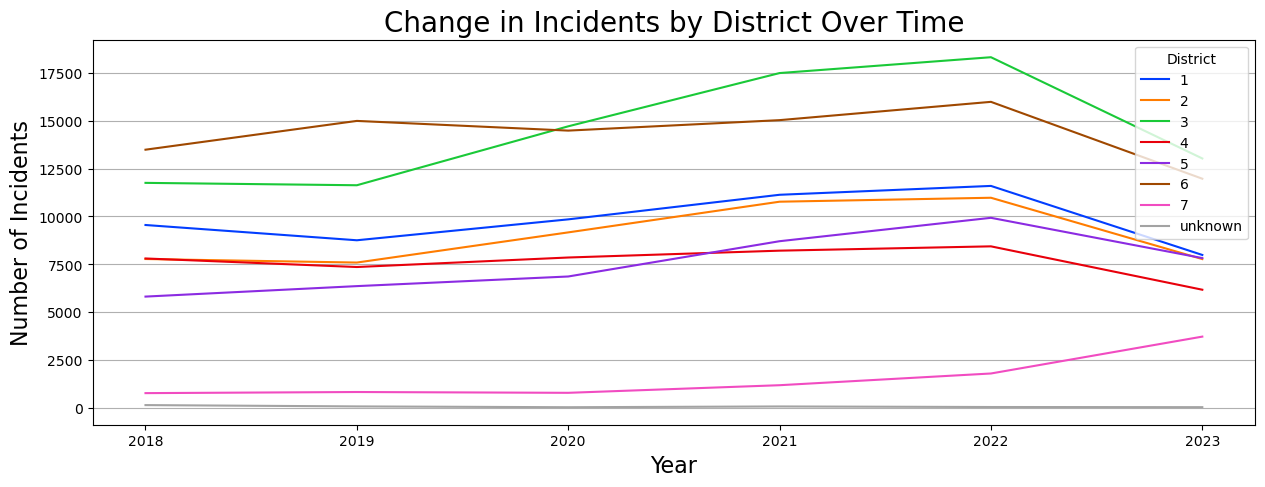

In [42]:
yearly_district_incidents_ax = sns.lineplot(
    data=yearly_district_incidents,
    x='first_occurrence_year_num',
    y='incident_id',
    hue='district_id',
    palette="bright"
    )

# Add title
yearly_district_incidents_ax.set_title('Change in Incidents by District Over Time', fontsize=20)

# Adjust axis labels
yearly_district_incidents_ax.set_xlabel('Year', fontsize=16)
yearly_district_incidents_ax.set_ylabel('Number of Incidents', fontsize=16)

# Adjust legend
plt.legend(fontsize=10, title="District")

fig = plt.gcf()
fig.set_size_inches(15,5)
sns.move_legend(yearly_district_incidents_ax, 'upper right')

yearly_district_incidents_ax.grid(visible=True, axis='y')
plt.savefig(
    'images/IncidentsOverTime_ChangeInIncidentsByDistrictOverTime[LineCharts].png',
    dpi=300,
    bbox_inches='tight'
    )
plt.show()

### Distribution [Histograms]

In [43]:
pd.concat([
    df.head(3).T,
    df.tail(3).T
], axis=1)

,0,1,2,386862,386863,386864
incident_id,202268791,2021387586,2020641486,2023533509,2023533048,2023532323
offense_id,202268791299900,2021387586299900,2020641486299900,2023533509131506,2023533048131506,2023532323131506
offense_code,2999,2999,2999,1315,1315,1315
offense_code_extension,0,0,0,6,6,6
offense_type,criminal-mischief-other,criminal-mischief-other,criminal-mischief-other,agg-aslt-shoot,agg-aslt-shoot,agg-aslt-shoot
offense_category,public-disorder,public-disorder,public-disorder,aggravated-assault,aggravated-assault,aggravated-assault
first_occurrence_timestamp,2022-02-10 02:50:00,2021-07-07 21:02:00,2020-10-29 01:30:00,2023-10-03 10:44:00,2023-10-03 05:30:00,2023-10-02 17:47:00
last_occurrence_timestamp,NaT,NaT,NaT,NaT,NaT,NaT
report_timestamp,2022-02-10 03:16:00,2021-07-08 00:55:00,2020-10-29 04:31:00,2023-10-03 12:03:00,2023-10-03 09:47:00,2023-10-02 18:16:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST,4745 N FEDERAL BLVD,N JOLIET ST / E 55TH AVE,585 S ALTON WAY,1198 N SHERIDAN BLVD


#### When do most incidents occur by hour?

In [44]:
df['first_occurrence_hour_num'] = df.first_occurrence_timestamp.dt.hour
df.head(3).T

,0,1,2
incident_id,202268791,2021387586,2020641486
offense_id,202268791299900,2021387586299900,2020641486299900
offense_code,2999,2999,2999
offense_code_extension,0,0,0
offense_type,criminal-mischief-other,criminal-mischief-other,criminal-mischief-other
offense_category,public-disorder,public-disorder,public-disorder
first_occurrence_timestamp,2022-02-10 02:50:00,2021-07-07 21:02:00,2020-10-29 01:30:00
last_occurrence_timestamp,NaT,NaT,NaT
report_timestamp,2022-02-10 03:16:00,2021-07-08 00:55:00,2020-10-29 04:31:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST,4745 N FEDERAL BLVD


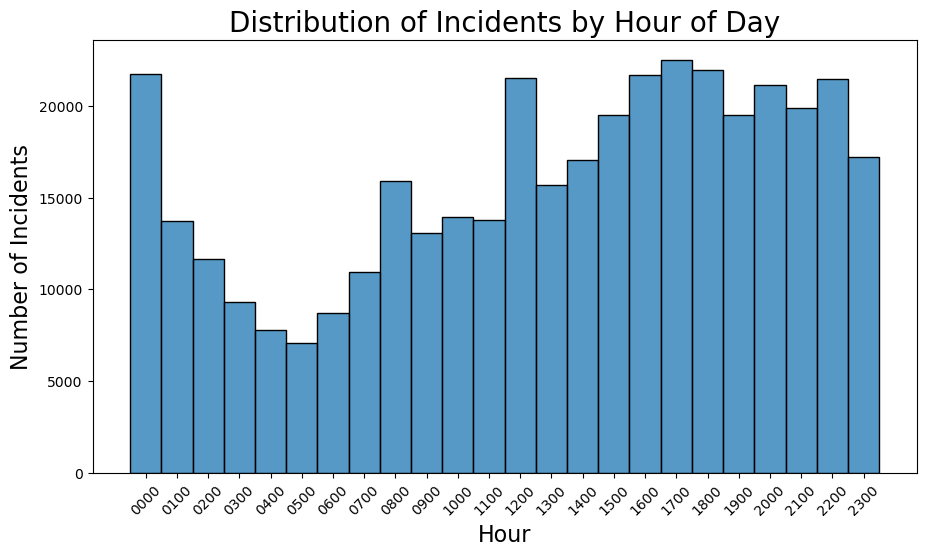

In [49]:
hourly_incidents_ax = sns.histplot(data=df, x='first_occurrence_hour_num', bins=24, stat='count')

hourly_incidents_ax.set_title('Distribution of Incidents by Hour of Day', fontsize=20)
hourly_incidents_ax.set_xlabel('Hour', fontsize=16)
hourly_incidents_ax.set_ylabel('Number of Incidents', fontsize=16)

# Calc center coordinate for each bin
centers = [patch.get_x() + patch.get_width() / 2 for patch in hourly_incidents_ax.patches]
# Dedup any overlapping categories
centers = sorted(list(set(centers)))
bin_labels = [f"0{i}00" if i < 10 else f"{i}00" for i in range(len(centers))]
plt.xticks(ticks=centers, labels=bin_labels, rotation=45)
plt.tight_layout()

fig = plt.gcf()
fig.set_size_inches(10, 6)

plt.savefig(
    'images/Distribution_IncidentsByHourOfDay[Histograms].png',
    dpi=300,
    bbox_inches='tight'
    )
plt.show()

#### When do most incidents occur by month?

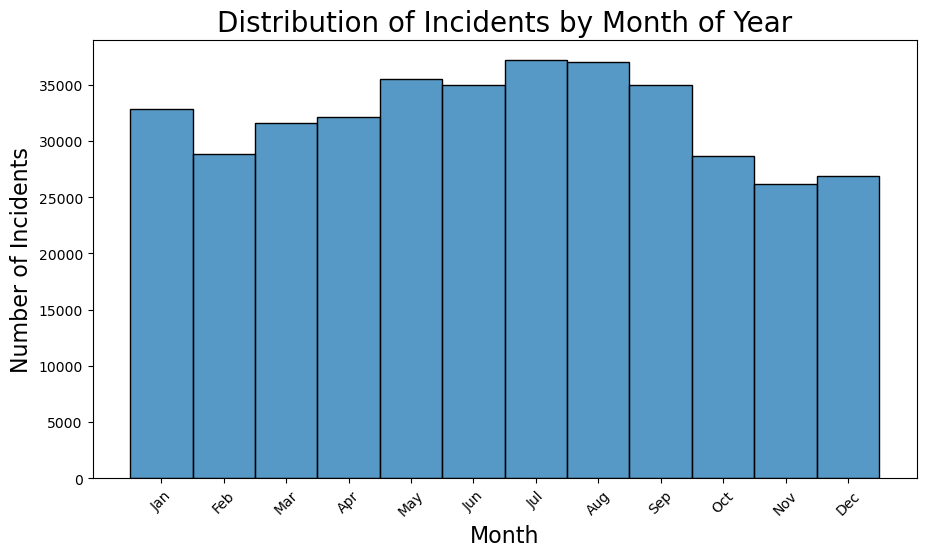

In [50]:
month_map = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}

monthly_incidents_ax = sns.histplot(data=df, x='first_occurrence_month_num', stat='count', bins=12)

monthly_incidents_ax.set_title('Distribution of Incidents by Month of Year', fontsize=20)
monthly_incidents_ax.set_xlabel('Month', fontsize=16)
monthly_incidents_ax.set_ylabel('Number of Incidents', fontsize=16)

# Calc center coordinate for each bin
centers = [patch.get_x() + patch.get_width() / 2 for patch in monthly_incidents_ax.patches]
# Dedup any overlapping categories
centers = sorted(list(set(centers)))
bin_labels = [month_map[i+1] for i in range(len(centers))]
plt.xticks(ticks=centers, labels=bin_labels, rotation=45)
plt.tight_layout()

fig = plt.gcf()
fig.set_size_inches(10, 6)

plt.savefig(
    'images/Distribution_IncidentsByMonthOfYear[Histograms].png',
    dpi=300,
    bbox_inches='tight',
    )
plt.show()

### Correlations [Scatterplots]

#### Is there a correlation between incidents and distance from city center?

In [51]:
DENVER_CENTER_COORDS = (39.742043, -104.991531) # lat lon

df['incident_distance_from_city_center_km'] = df.apply(
    lambda x: round(geodesic(
        DENVER_CENTER_COORDS, 
        (x['incident_latitude'], x['incident_longitude'])).km, 2), 
        axis=1)

df.head(3).T

,0,1,2
incident_id,202268791,2021387586,2020641486
offense_id,202268791299900,2021387586299900,2020641486299900
offense_code,2999,2999,2999
offense_code_extension,0,0,0
offense_type,criminal-mischief-other,criminal-mischief-other,criminal-mischief-other
offense_category,public-disorder,public-disorder,public-disorder
first_occurrence_timestamp,2022-02-10 02:50:00,2021-07-07 21:02:00,2020-10-29 01:30:00
last_occurrence_timestamp,NaT,NaT,NaT
report_timestamp,2022-02-10 03:16:00,2021-07-08 00:55:00,2020-10-29 04:31:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST,4745 N FEDERAL BLVD


In [52]:
df.incident_distance_from_city_center_km.describe()

count    386865.000000
mean        467.717608
std        2233.885184
min           0.010000
25%           2.320000
50%           5.320000
75%           9.420000
max       11290.540000
Name: incident_distance_from_city_center_km, dtype: float64

In [53]:
distance_grouped_incidents = df.groupby(['incident_distance_from_city_center_km', 'is_violent_crime'])['incident_id'].count().reset_index()
distance_grouped_incidents.sort_values(by='incident_id', ascending=False, inplace=True)
distance_grouped_incidents

,incident_distance_from_city_center_km,is_violent_crime,incident_id
4485,11290.54,True,13355
4484,11290.54,False,2453
75,0.42,False,2437
4447,29.80,False,2078
101,0.55,False,1868
...,...,...,...
2480,12.46,True,1
4311,25.66,False,1
4312,25.66,True,1
4142,21.92,True,1


In [55]:
# The outmost distance boundary of Denver is the NE edge of Denver International Airport (~35 km from city center)
# This is just a rough value because the city is not a simple simple with a constant perimeter or circumference
# So we should filter out results beyond this 35 km limit

filtered_distance_incidents = distance_grouped_incidents.query('incident_distance_from_city_center_km <= 35')
filtered_distance_incidents

,incident_distance_from_city_center_km,is_violent_crime,incident_id
75,0.42,False,2437
4447,29.80,False,2078
101,0.55,False,1868
1709,8.59,False,1549
4332,26.50,False,1378
...,...,...,...
2480,12.46,True,1
4311,25.66,False,1
4312,25.66,True,1
4142,21.92,True,1


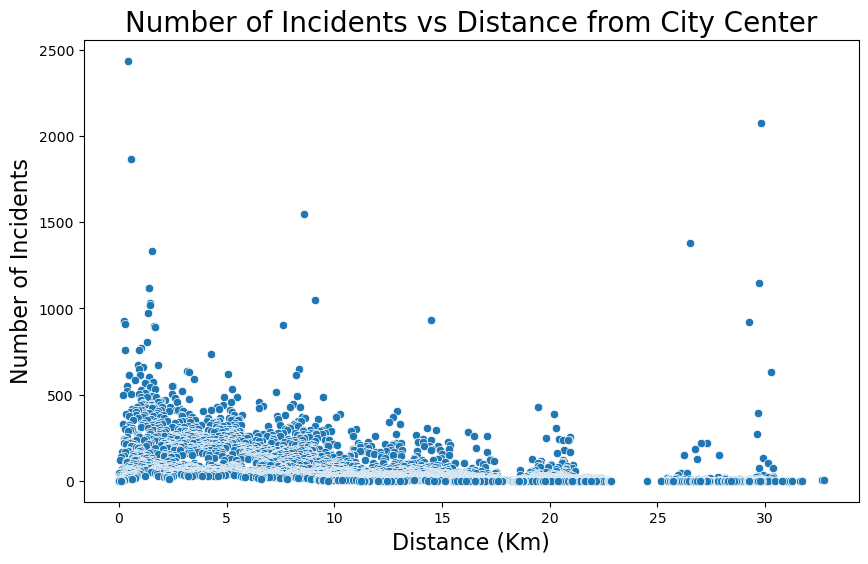

In [56]:
incidents_distance_ax = sns.scatterplot(data=filtered_distance_incidents, x='incident_distance_from_city_center_km', y='incident_id')

incidents_distance_ax.set_title("Number of Incidents vs Distance from City Center", fontsize=20)
incidents_distance_ax.set_xlabel("Distance (Km)", fontsize=16)
incidents_distance_ax.set_ylabel("Number of Incidents", fontsize=16)

fig = plt.gcf()
fig.set_size_inches(10, 6)

plt.savefig(
    'images/Correlation_IncidentsVsDistance[Scatterplots].png',
    dpi=300,
    bbox_inches='tight',
    )
plt.show()

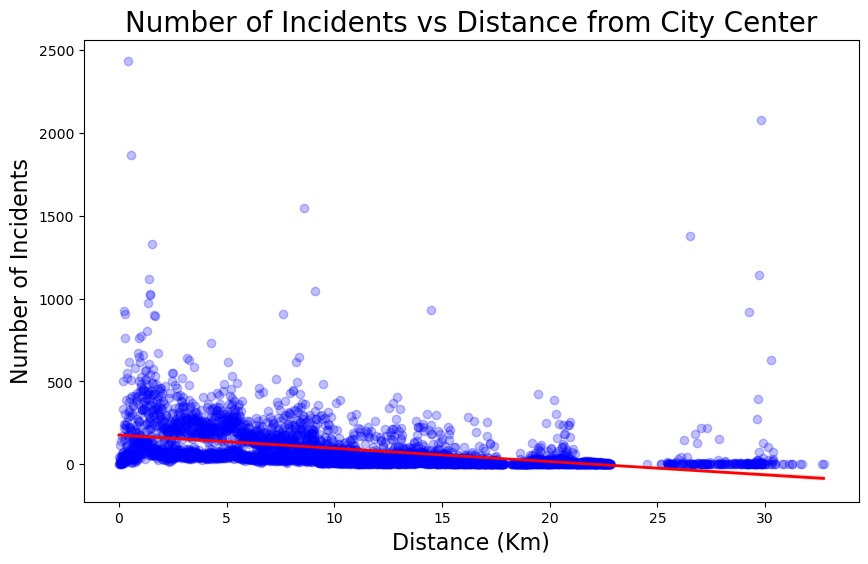

In [57]:
incidents_distance_regression_ax = sns.regplot(
    data=filtered_distance_incidents, 
    x='incident_distance_from_city_center_km', 
    y='incident_id',
    scatter_kws={'color': 'blue', 'alpha': 0.25},
    line_kws={'color': 'red', 'linewidth': 2},
    )

incidents_distance_regression_ax.set_title("Number of Incidents vs Distance from City Center", fontsize=20)
incidents_distance_regression_ax.set_xlabel("Distance (Km)", fontsize=16)
incidents_distance_regression_ax.set_ylabel("Number of Incidents", fontsize=16)

fig = plt.gcf()
fig.set_size_inches(10, 6)

plt.savefig(
    'images/Correlation_IncidentsVsDistanceRegression[Scatterplots].png',
    dpi=300,
    bbox_inches='tight',
    )
plt.show()

### Geo Plots

In [58]:
neighborhoods = df.neighborhood_name.unique().tolist()
neighborhoods.sort()
neighborhoods

['athmar-park',
 'auraria',
 'baker',
 'barnum',
 'barnum-west',
 'bear-valley',
 'belcaro',
 'berkeley',
 'capitol-hill',
 'cbd',
 'central-park',
 'chaffee-park',
 'cheesman-park',
 'cherry-creek',
 'city-park',
 'city-park-west',
 'civic-center',
 'clayton',
 'cole',
 'college-view-south-platte',
 'congress-park',
 'cory-merrill',
 'country-club',
 'dia',
 'east-colfax',
 'elyria-swansea',
 'five-points',
 'fort-logan',
 'gateway-green-valley-ranch',
 'globeville',
 'goldsmith',
 'hale',
 'hampden',
 'hampden-south',
 'harvey-park',
 'harvey-park-south',
 'highland',
 'hilltop',
 'indian-creek',
 'jefferson-park',
 'kennedy',
 'lincoln-park',
 'lowry-field',
 'mar-lee',
 'marston',
 'montbello',
 'montclair',
 'north-capitol-hill',
 'north-park-hill',
 'northeast-park-hill',
 'overland',
 'platt-park',
 'regis',
 'rosedale',
 'ruby-hill',
 'skyland',
 'sloan-lake',
 'south-park-hill',
 'southmoor-park',
 'speer',
 'sun-valley',
 'sunnyside',
 'union-station',
 'university',
 'univer

In [59]:
all_lats = df.query('incident_latitude != ""').incident_latitude.tolist()
all_lons = df.query('incident_longitude != ""').incident_longitude.tolist()

MEAN_LAT = statistics.mean(all_lats)
MEAN_LON = statistics.mean(all_lons)

print("mean lat", MEAN_LAT, "mean lon", MEAN_LON)

mean lat 39.73060696073657 mean lon -104.94289635881712


In [60]:
# https://opendata-geospatialdenver.hub.arcgis.com/datasets/3e57d472afbf4326867c1a4c9d4e7c91_13/explore?location=39.700312%2C-104.904305%2C11
with open("source_data\denver_nbhds.geojson", "r") as f:
    geojson_data = json.load(f)

geojson_data.keys()

dict_keys(['type', 'crs', 'features'])

In [61]:
cleaned_nbd_name_df = df.copy()

nbd_rename_map = {
    'Cbd': 'CBD',
    'Cory Merrill': 'Cory - Merrill',
    'Dia': 'DIA',
    'Gateway Green Valley Ranch': 'Gateway - Green Valley Ranch'
}

cleaned_nbd_name_df.neighborhood_name = cleaned_nbd_name_df.neighborhood_name.apply(lambda x: x.replace('-', ' ').title())
cleaned_nbd_name_df.neighborhood_name = cleaned_nbd_name_df.neighborhood_name.replace(nbd_rename_map)
cleaned_nbd_name_df.neighborhood_name.unique()

array(['Lincoln Park', 'CBD', 'Berkeley', 'Barnum', 'Montbello',
       'Highland', 'Capitol Hill', 'Clayton', 'Congress Park', 'Whittier',
       'Barnum West', 'Gateway - Green Valley Ranch', 'Central Park',
       'Platt Park', 'North Capitol Hill', 'Athmar Park', 'Union Station',
       'Washington Virginia Vale', 'Northeast Park Hill', 'West Colfax',
       'Five Points', 'Westwood', 'Civic Center', 'Sunnyside',
       'Cheesman Park', 'City Park West', 'Baker', 'East Colfax',
       'Skyland', 'University Hills', 'Overland', 'West Highland',
       'Valverde', 'College View South Platte', 'Jefferson Park',
       'Cherry Creek', 'Hale', 'Harvey Park South', 'Hampden', 'Rosedale',
       'Globeville', 'Goldsmith', 'Lowry Field', 'Speer',
       'Elyria Swansea', 'Chaffee Park', 'Villa Park', 'Sun Valley',
       'DIA', 'Cory - Merrill', 'Cole', 'Harvey Park',
       'Washington Park West', 'Washington Park', 'Mar Lee', 'University',
       'Bear Valley', 'Hampden South', 'Belcaro'

#### What is the geographic distribution of violent incidents by neighborhood?

In [62]:
cleaned_nbd_violent_df = cleaned_nbd_name_df.query('is_violent_crime == True').groupby(['neighborhood_name'])['incident_id'].count().reset_index()
cleaned_nbd_violent_df.head()

cleaned_nbd_violent_df = cleaned_nbd_violent_df.rename(mapper={
    'neighborhood_name': 'Neighborhood',
    'incident_id': 'Number of Incidents',
}, axis=1)

cleaned_nbd_violent_df

,Neighborhood,Number of Incidents
0,Athmar Park,868
1,Auraria,437
2,Baker,1251
3,Barnum,653
4,Barnum West,353
...,...,...
74,West Colfax,1861
75,West Highland,671
76,Westwood,1673
77,Whittier,539


In [65]:
nbd_violent_crime_fig = px.choropleth_map(
    cleaned_nbd_violent_df,
    geojson=geojson_data,
    locations='Neighborhood',
    featureidkey='properties.NBHD_NAME',
    color='Number of Incidents',
    color_continuous_scale='reds',
    opacity=0.5,
    map_style='carto-positron',
    center={'lat': MEAN_LAT, 'lon': MEAN_LON},
    zoom=9,
    width=1000,
    height=700,
    title="Violent Incident Concentration by Neighborhood",
    )

nbd_violent_crime_fig.write_image(
    'images/GeoPlots_ViolentIncidentConcentrationByNeighborhood[Chloropleths].png',
    format='png',
    width=1000,
    height=700,
    scale=5
    )
nbd_violent_crime_fig.show()

In [67]:
cleaned_nbd_nonviolent_df = cleaned_nbd_name_df.query('is_violent_crime == False').groupby(['neighborhood_name'])['incident_id'].count().reset_index()

cleaned_nbd_nonviolent_df = cleaned_nbd_nonviolent_df.rename(mapper={
    'neighborhood_name': 'Neighborhood',
    'incident_id': 'Number of Incidents',
}, axis=1)

cleaned_nbd_nonviolent_df

,Neighborhood,Number of Incidents
0,Athmar Park,3031
1,Auraria,2774
2,Baker,5601
3,Barnum,2294
4,Barnum West,1549
...,...,...
74,West Colfax,6547
75,West Highland,2945
76,Westwood,5397
77,Whittier,1824


In [69]:
nbd_nonviolent_crime_fig = px.choropleth_map(
    cleaned_nbd_nonviolent_df,
    geojson=geojson_data,
    locations='Neighborhood',
    featureidkey='properties.NBHD_NAME',
    color='Number of Incidents',
    color_continuous_scale='reds',
    opacity=0.5,
    map_style='carto-positron',
    center={'lat': MEAN_LAT, 'lon': MEAN_LON},
    zoom=9,
    width=1000,
    height=700,
    title="Non-Violent Incident Concentration by Neighborhood",
    )

nbd_nonviolent_crime_fig.write_image(
    'images/GeoPlots_NonViolentIncidentConcentrationByNeighborhood[Chloropleths].png',
    format='png',
    width=1000,
    height=700,
    scale=5
    )

nbd_nonviolent_crime_fig.show()